In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


In [4]:
base_dir = "/content/drive/MyDrive/project"

train_dir = os.path.join(base_dir, "train_images")
test_dir = os.path.join(base_dir, "test_images")

model_path = os.path.join(base_dir, "cvae_deepfashion_200.pth")

print("Base folder:", base_dir)
print("Train folder:", train_dir)
print("Test folder:", test_dir)
print("Model path:", model_path)

print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))

Base folder: /content/drive/MyDrive/project
Train folder: /content/drive/MyDrive/project/train_images
Test folder: /content/drive/MyDrive/project/test_images
Model path: /content/drive/MyDrive/project/cvae_deepfashion_200.pth
Train folder exists: True
Test folder exists: True


In [5]:
image_size = 200

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [6]:
class FashionImageDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform

        self.image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
        ]

        self.image_files = sorted(self.image_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image_name = self.image_files[index]
        image_path = os.path.join(self.folder_path, image_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, 0

In [7]:
train_dataset_full = FashionImageDataset(train_dir, transform=transform)
test_dataset = FashionImageDataset(test_dir, transform=transform)

print("Total train images:", len(train_dataset_full))
print("Total test images:", len(test_dataset))

Total train images: 3800
Total test images: 1149


In [8]:
sample_image_name = train_dataset_full.image_files[0]
sample_image_path = os.path.join(train_dir, sample_image_name)

sample_image = Image.open(sample_image_path)

print("Sample image name:", sample_image_name)
print("Original image mode:", sample_image.mode)

sample_image_rgb = sample_image.convert("RGB")

print("After conversion mode:", sample_image_rgb.mode)
print("Number of channels:", len(sample_image_rgb.getbands()))

Sample image name: WOMEN-Rompers_Jumpsuits-id_00006578-01_7_additional.png
Original image mode: RGB
After conversion mode: RGB
Number of channels: 3


In [9]:
subset_size = 2000

if len(train_dataset_full) < subset_size:
    subset_size = len(train_dataset_full)

indices = list(range(len(train_dataset_full)))
random.shuffle(indices)

train_subset = Subset(train_dataset_full, indices[:subset_size])

print("Training subset size:", len(train_subset))

Training subset size: 2000


In [10]:
batch_size = 10

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 200
Test batches: 115


In [11]:
def denormalize(img):
    return img * 0.5 + 0.5

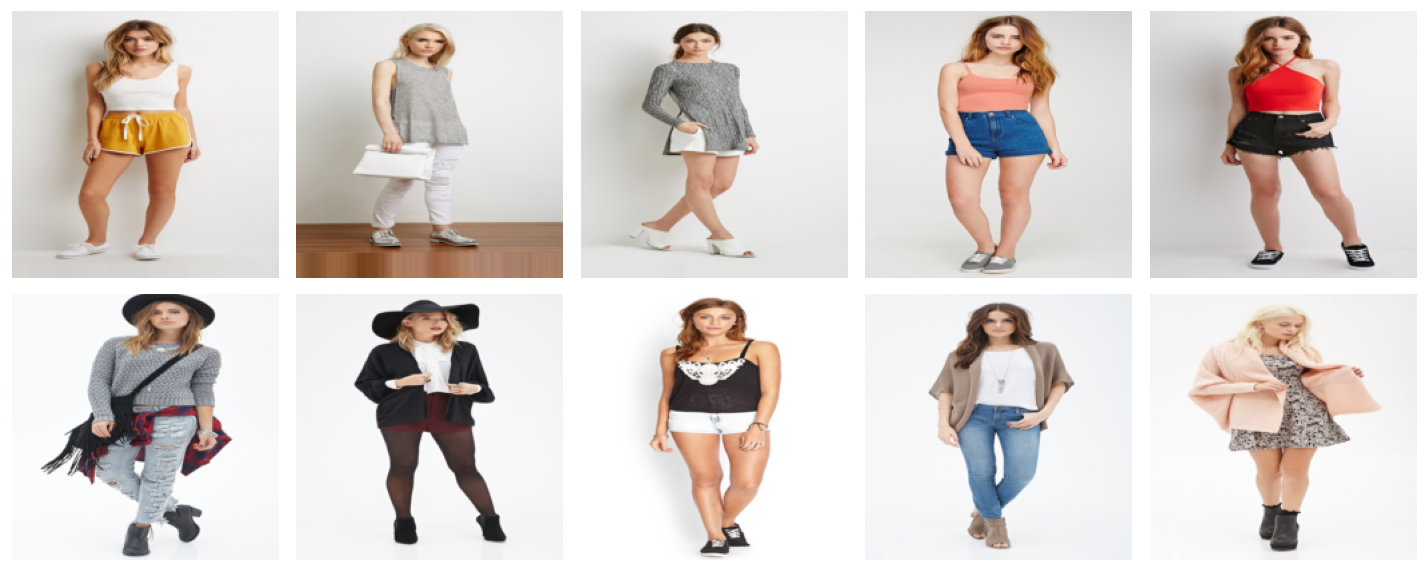

In [12]:
display_loader = DataLoader(
    train_subset,
    batch_size=10,
    shuffle=True,
    num_workers=2
)

data_iter = iter(display_loader)
images, labels = next(data_iter)

fig, axes = plt.subplots(2, 5, figsize=(12, 5), dpi=120)

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=128, input_image_size=200):
        super(CVAE, self).__init__()

        self.latent_dim = latent_dim
        self.input_image_size = input_image_size

        # Encoder: 200 -> 100 -> 50 -> 25
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.feature_size = input_image_size // 8
        self.flatten_dim = 128 * self.feature_size * self.feature_size

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        # Decoder: 25 -> 50 -> 100 -> 200
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10, max=10)

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    def decode(self, z):
        x = self.fc_decode(z)

        x = x.view(-1, 128, self.feature_size, self.feature_size)

        x = self.decoder(x)

        return x

    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        reconstructed = self.decode(z)

        return reconstructed, mu, logvar

In [14]:
def vae_loss(reconstructed, original, mu, logvar, beta=0.0001):
    logvar = torch.clamp(logvar, min=-10, max=10)

    mse_loss = nn.functional.mse_loss(reconstructed, original, reduction='mean')

    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = mse_loss + beta * kl_loss

    return total_loss, mse_loss, kl_loss

In [15]:
latent_dim = 128

model = CVAE(latent_dim=latent_dim, input_image_size=image_size).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

print(model)

CVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (fc_mu): Linear(in_features=80000, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=80000, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=80000, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
   

In [16]:
for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_mse = 0
    total_kl = 0
    valid_batches = 0

    for images, _ in train_loader:
        images = images.to(device)

        if torch.isnan(images).any() or torch.isinf(images).any():
            print("Skipped batch because image tensor contains NaN or Inf")
            continue

        optimizer.zero_grad()

        reconstructed, mu, logvar = model(images)

        loss, mse, kl = vae_loss(reconstructed, images, mu, logvar)

        if torch.isnan(loss) or torch.isinf(loss):
            print("Skipped batch because loss became NaN or Inf")
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        total_mse += mse.item()
        total_kl += kl.item()
        valid_batches += 1

    if valid_batches > 0:
        avg_loss = total_loss / valid_batches
        avg_mse = total_mse / valid_batches
        avg_kl = total_kl / valid_batches

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}, MSE: {avg_mse:.4f}, KL: {avg_kl:.4f}")
    else:
        print(f"Epoch [{epoch+1}/{epochs}] No valid batches found.")

Epoch [1/10] Loss: 0.3742, MSE: 0.1637, KL: 2105.0029
Epoch [2/10] Loss: 0.2992, MSE: 0.0927, KL: 2064.3356
Epoch [3/10] Loss: 0.2677, MSE: 0.0719, KL: 1958.1270
Epoch [4/10] Loss: 0.1947, MSE: 0.0640, KL: 1306.8223
Epoch [5/10] Loss: 0.0928, MSE: 0.0550, KL: 378.2281
Epoch [6/10] Loss: 0.0526, MSE: 0.0505, KL: 20.9771
Epoch [7/10] Loss: 0.0467, MSE: 0.0455, KL: 11.9434
Epoch [8/10] Loss: 0.0428, MSE: 0.0418, KL: 9.6622
Epoch [9/10] Loss: 0.0397, MSE: 0.0388, KL: 9.2257
Epoch [10/10] Loss: 0.0366, MSE: 0.0358, KL: 8.2020


Original min: -1.0 Original max: 0.9921568632125854
Reconstructed min: -0.8932134509086609 Reconstructed max: 0.9867450594902039
Any NaN in reconstructed: False


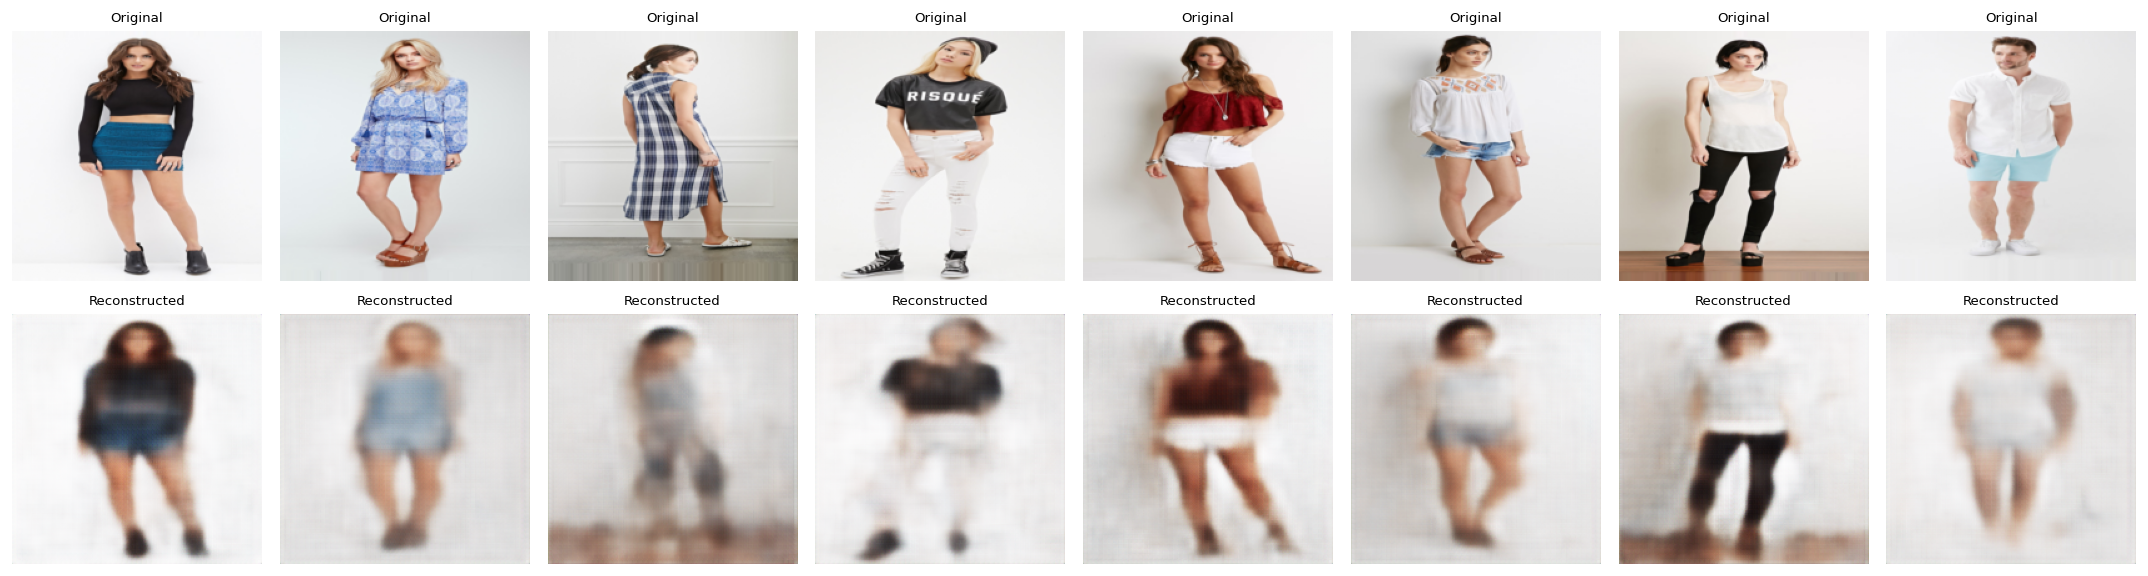

In [17]:
model.eval()

reconstruction_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

test_iter = iter(reconstruction_loader)
test_images, _ = next(test_iter)

test_images = test_images.to(device)

with torch.no_grad():
    reconstructed, _, _ = model(test_images)

test_images = test_images.cpu()
reconstructed = reconstructed.cpu()

print("Original min:", test_images.min().item(), "Original max:", test_images.max().item())
print("Reconstructed min:", reconstructed.min().item(), "Reconstructed max:", reconstructed.max().item())
print("Any NaN in reconstructed:", torch.isnan(reconstructed).any().item())

fig, axes = plt.subplots(2, 8, figsize=(18, 5), dpi=120)

for i in range(8):
    original_img = denormalize(test_images[i]).permute(1, 2, 0)
    recon_img = denormalize(reconstructed[i]).permute(1, 2, 0)

    original_img = torch.clamp(original_img, 0, 1)
    recon_img = torch.clamp(recon_img, 0, 1)

    axes[0, i].imshow(original_img)
    axes[0, i].axis("off")
    axes[0, i].set_title("Original", fontsize=8)

    axes[1, i].imshow(recon_img)
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstructed", fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
torch.save(model.state_dict(), model_path)

print("Model saved successfully at:")
print(model_path)

Model saved successfully at:
/content/drive/MyDrive/project/cvae_deepfashion_200.pth


In [19]:
loaded_model = CVAE(latent_dim=latent_dim, input_image_size=image_size).to(device)

loaded_model.load_state_dict(torch.load(model_path, map_location=device))

loaded_model.eval()

print("Model loaded successfully for inference.")

Model loaded successfully for inference.


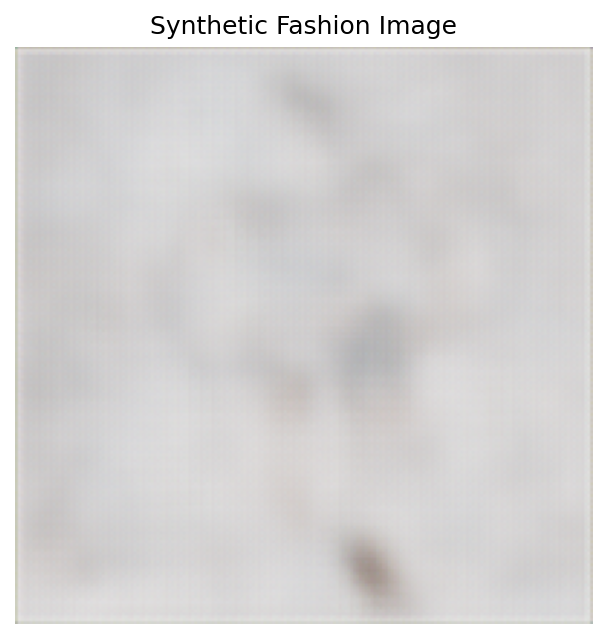

In [20]:
loaded_model.eval()

with torch.no_grad():
    z = torch.randn(1, latent_dim).to(device) * 0.7
    generated_image = loaded_model.decode(z)

generated_image = generated_image.cpu().squeeze(0)
generated_image = denormalize(generated_image).permute(1, 2, 0)
generated_image = torch.clamp(generated_image, 0, 1)

plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(generated_image)
plt.axis("off")
plt.title("Synthetic Fashion Image")
plt.show()

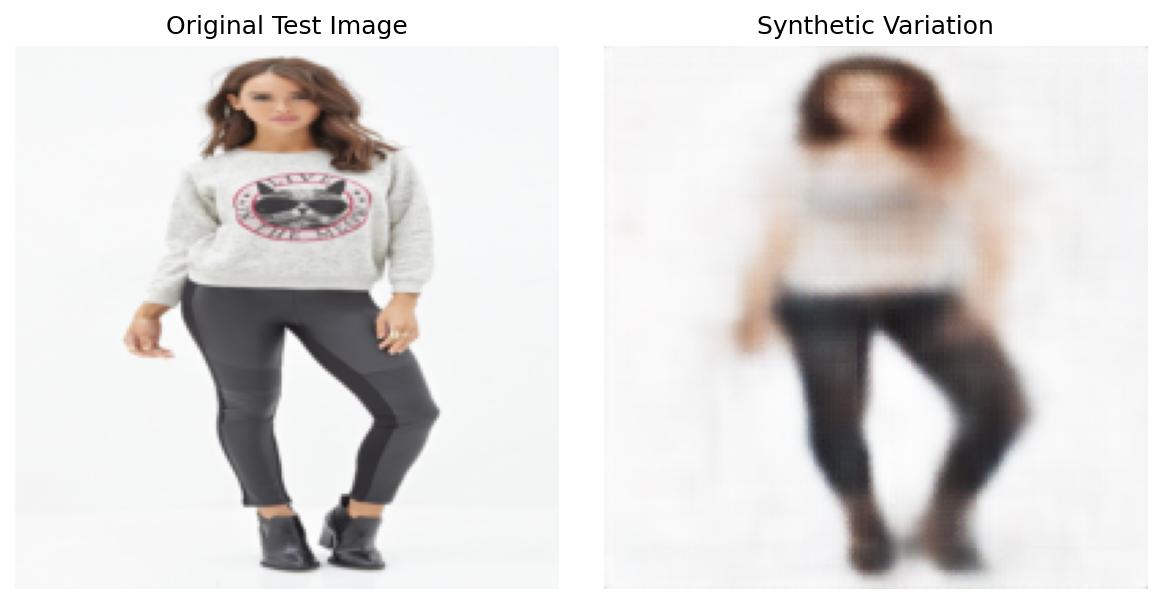

In [21]:
loaded_model.eval()

variation_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2
)

test_iter = iter(variation_loader)
test_image, _ = next(test_iter)

test_image = test_image.to(device)

with torch.no_grad():
    mu, logvar = loaded_model.encode(test_image)

    noise = torch.randn_like(mu) * 0.3

    z = mu + noise

    generated_variation = loaded_model.decode(z)

original = denormalize(test_image.cpu().squeeze(0)).permute(1, 2, 0)
generated_variation = denormalize(generated_variation.cpu().squeeze(0)).permute(1, 2, 0)

original = torch.clamp(original, 0, 1)
generated_variation = torch.clamp(generated_variation, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=150)

axes[0].imshow(original)
axes[0].axis("off")
axes[0].set_title("Original Test Image")

axes[1].imshow(generated_variation)
axes[1].axis("off")
axes[1].set_title("Synthetic Variation")

plt.tight_layout()
plt.show()

In [22]:
print("Final Project Settings")
print("----------------------")
print("Image size:", image_size, "x", image_size)
print("Training subset size:", len(train_subset))
print("Batch size:", batch_size)
print("Latent dimension:", latent_dim)
print("Epochs:", epochs)
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Loss: MSE + KL Divergence")
print("Model class name: CVAE")
print("Device:", device)

Final Project Settings
----------------------
Image size: 200 x 200
Training subset size: 2000
Batch size: 10
Latent dimension: 128
Epochs: 10
Optimizer: Adam
Learning rate: 0.0001
Loss: MSE + KL Divergence
Model class name: CVAE
Device: cuda
